# 로지스틱 회귀
* 선형 회귀 방식을 분류에 적용한 알고리즘
* 선형 회귀계열임 (회귀가 선형인가 비선형인가는, 독립변수가 아닌 가중치 변수(weight)가 선형인지 아닌지를 따짐!)
* 선형 회귀와 차이점 : 학습 통해 선형 함수의 회귀 최적선을 찾는 것이 아님. 시그모이드 함수 최적선 찾고 이 함수의 반환값을 확류로 간주해 확률에 따라 분류를 결정함
* 시그모이드 함수 사용 시, 좀 더 정확하게 0, 1 대해 분류 가능
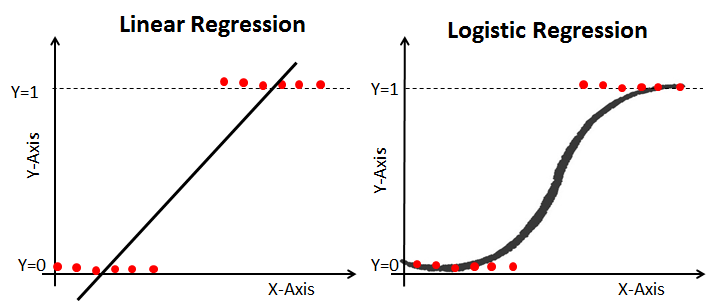
* 가볍고 빠르며 이진 분류 예측 성능 뛰어남, 희소한 데이터 세트 분류에서도 성능 뛰어나 텍스트 분류에도 사용
* 사이킷런 LogisticRegression 클래스
  * 파라미터 penalty : 규제 유형 설정
  * 파라미터 C : 규제 강도 조절하는 알파값의 역수. 작을 수록 규제 강도 큼

# 위스콘신 유방암 데이터셋

In [9]:
### 모듈 임포트

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score

In [8]:
cancer = load_breast_cancer()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

x_train, x_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size=0.3, random_state=0)

lr_clf = LogisticRegression()
lr_clf.fit(x_train, y_train)
lr_pred = lr_clf.predict(x_test)

print('accuracy : {0:.3f}'.format(accuracy_score(y_test, lr_pred)))
print('roc auc : {0:.3f}'.format(roc_auc_score(y_test, lr_pred)))

accuracy : 0.977
roc auc : 0.972


In [10]:
### 하이퍼 파라미터 최적화

params = {'penalty':['l2', 'l1'], 'C':[0.01, 0.1, 1, 1, 5, 10]}
grid_clf = GridSearchCV(lr_clf, param_grid=params, scoring='accuracy', cv=3)
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터 : {0}, 최적 평균 정확도 : {1:.3f}'.format(grid_clf.best_params_, grid_clf.best_score_))

C:\Users\lumos\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:548: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\lumos\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 531, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\lumos\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1304, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\lumos\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 442, in _check_solver
    raise ValueError("Solver %s supports only 'l2' or 'none' penalties, "
ValueError: Solver lbfgs supports only 'l2' or 'none' penalties, got l1 penalty.

  warnings.warn("Estimator fit failed. The score on this train-test"
C:\Users\lumos\anaconda3\lib\site-packages\sklearn\model_selection\_v

최적 하이퍼 파라미터 : {'C': 1, 'penalty': 'l2'}, 최적 평균 정확도 : 0.975


C:\Users\lumos\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:548: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\lumos\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 531, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\lumos\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1304, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\lumos\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 442, in _check_solver
    raise ValueError("Solver %s supports only 'l2' or 'none' penalties, "
ValueError: Solver lbfgs supports only 'l2' or 'none' penalties, got l1 penalty.

  warnings.warn("Estimator fit failed. The score on this train-test"
